# HEALPix → UTM: extract a small UTM zone from a large HEALPix dataset

This notebook shows how to convert data stored on HEALPix cells — `cell_ids` and `data[B, N]`, where `B` is a batch
dimension (bands, time steps, …) — into a regular raster `x, y` in the UTM projection of a tile.

The important point is the **order of operations**. A metre-scale HEALPix dataset covering the Earth is far larger
than memory (terabytes to petabytes in a Zarr store), so the data can never be loaded first. Instead:

1. **describe the target**: the `x`, `y` pixel centres of the zone and the CRS of the tile;
2. **build the operator** from that geometry only — this tells us *which HEALPix cells are needed*;
3. **read only those cells** from the store;
4. **apply the operator** to the data that were read.

Steps 1–2 never touch the dataset: their cost depends on the size of the raster, not on the size of the archive.

Requirements: `healpix-resample` with the optional `pyproj` dependency (`pip install healpix-resample[utm]`), and
`matplotlib` for the figures.

In [1]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
import healpix_geo

# torch emits informational warnings about its sparse-tensor backend
warnings.filterwarnings("ignore", message=".*[Ss]parse.*")

from healpix_resample import HealpixToUTM, UTMGrid

## The source dataset

To keep the notebook self-contained (no download), the "store" below is a function that returns the values of
any requested cells, computed analytically. It stands for a selection in a real Zarr store (see
[the last section](#With-a-real-Zarr-store)); what matters is its interface: **cell ids in, `data[B, K]` out**.

The dataset is *global* at HEALPix level 19 (cells of about 12 m), with `B = 3` fields. It is never materialised.

In [2]:
LEVEL = 19                 # HEALPix level of the dataset (nested scheme)
B = 3                      # batch dimension: bands, dates, ...
WAVELENGTHS_M = (400.0, 700.0, 1200.0)
R = 6371000.0

n_cells_global = 12 * 4**LEVEL
cell_size_m = np.sqrt(4 * np.pi / n_cells_global) * R
print(f"global dataset: {n_cells_global:.2e} cells of ~{cell_size_m:.1f} m, "
      f"{B * n_cells_global * 4 / 1e12:.0f} TB as float32")


def field(lon_deg, lat_deg):
    """The 'true' geophysical fields, defined everywhere: shape (B,) + lon.shape."""
    lon_deg = (np.asarray(lon_deg) + 180.0) % 360.0 - 180.0   # same convention for [0, 360) and [-180, 180)
    xm = R * np.radians(lon_deg) * np.cos(np.radians(48.3))
    ym = R * np.radians(lat_deg)
    return np.stack([np.sin(2 * np.pi * xm / w) * np.cos(2 * np.pi * ym / w) for w in WAVELENGTHS_M])


def read_cells(cell_ids):
    """Stand-in for the store: return data[B, K] for the requested cell ids only."""
    lon, lat = healpix_geo.nested.healpix_to_lonlat(
        np.asarray(cell_ids, dtype=np.uint64), LEVEL, ellipsoid="WGS84"
    )
    return field(np.asarray(lon), np.asarray(lat)).astype(np.float32)

global dataset: 3.30e+12 cells of ~12.4 m, 40 TB as float32


## 1. The target zone: `x`, `y` and the reference of the tile

The zone is described by the pixel-centre coordinates `x` (eastings) and `y` (northings) and by the CRS of the
tile they belong to. Here: a 2 km × 2 km zone at 10 m in UTM zone 30N (`EPSG:32630`), the projection of the
Sentinel-2 tiles over Brittany. `y` is decreasing (north-up raster).

In [3]:
TILE_EPSG = 32630          # CRS of the tile (WGS 84 / UTM zone 30N)
RES = 10.0                 # pixel size (m)

x = 400000.0 + RES * (np.arange(200) + 0.5)     # (nx,) pixel centres
y = 5360000.0 - RES * (np.arange(200) + 0.5)    # (ny,) pixel centres, north-up

grid = UTMGrid(crs=TILE_EPSG, x=x, y=y)
print("raster shape (ny, nx):", grid.shape, "|", grid.crs.name)

raster shape (ny, nx): (200, 200) | WGS 84 / UTM zone 30N


`UTMGrid.from_bounds(crs, (xmin, ymin, xmax, ymax), resolution)` builds the same object from the outer edges
of the zone.

## 2. Build the operator: which cells are needed?

`HealpixToUTM` is built from the grid and the HEALPix level only. Internally it reprojects the pixel centres to
longitude/latitude, builds a resampler on those points, and will later apply that resampler's `invert()`
(HEALPix cells → points). Building the resampler is what determines the cells the raster depends on, exposed
as `op.cell_ids` (sorted, unique).

In [4]:
op = HealpixToUTM(grid, LEVEL, method="bilinear")

print(f"cells needed: K = {op.K}")
print(f"fraction of the global dataset: {op.K / n_cells_global:.1e}")
print("first ids:", op.cell_ids[:4])

cells needed: K = 26353
fraction of the global dataset: 8.0e-09
first ids: [925142264303 925142264307 925142264312 925142264313]


## 3. Read only those cells

This is the only access to the dataset, and it is limited to `K` cells.

In [5]:
data = read_cells(op.cell_ids)
print("data:", data.shape, data.dtype, f"({data.nbytes / 1e6:.2f} MB)")

data: (3, 26353) float32 (0.32 MB)


## 4. Apply the operator

`resample` takes `data[B, K]` (or a single field `data[K]`) and returns `image[B, ny, nx]`. The operator can be
reused for any other data defined on the same cells — other dates, other variables — without being rebuilt.

In [6]:
image = op.resample(data)
print("image:", image.shape, image.dtype)

image: (3, 200, 200) float64


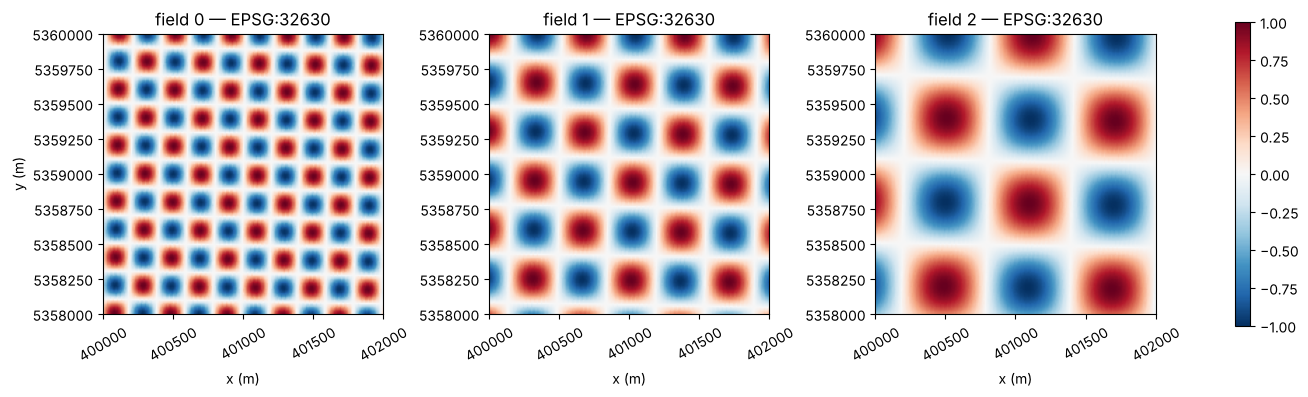

In [7]:
extent = [grid.x[0] - RES / 2, grid.x[-1] + RES / 2, grid.y[-1] - RES / 2, grid.y[0] + RES / 2]

fig, axes = plt.subplots(1, B, figsize=(13, 4.2), constrained_layout=True)
for b, ax in enumerate(axes):
    im = ax.imshow(image[b], extent=extent, origin="upper", vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(f"field {b} — EPSG:{TILE_EPSG}")
    ax.set_xlabel("x (m)")
    ax.ticklabel_format(style="plain", useOffset=False)
    ax.tick_params(axis="x", labelrotation=30)
axes[0].set_ylabel("y (m)")
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

## Choosing the interpolation method

`method` selects which resampler's `invert()` is used. Since the test field is analytic, the result can be
compared with the truth at the pixel centres. Each method needs a slightly different set of cells, so the read
is repeated with each operator's own `cell_ids`.

In [8]:
lon_pix, lat_pix = grid.lonlat()
truth = field(lon_pix, lat_pix)

print(f"{'method':<15}{'K':>8}{'rms error':>12}{'max error':>12}")
for method in ["nearest", "bilinear", "bicubic", "clough_tocher"]:
    op_m = HealpixToUTM(grid, LEVEL, method=method)
    err = op_m.resample(read_cells(op_m.cell_ids)) - truth
    print(f"{method:<15}{op_m.K:>8}{np.sqrt(np.nanmean(err**2)):>12.1e}{np.nanmax(np.abs(err)):>12.1e}")

method                K   rms error   max error
nearest           25987     3.2e-02     1.6e-01


bilinear          26353     9.9e-03     5.4e-02


bicubic           26378     1.0e-02     7.5e-02


clough_tocher     27195     9.4e-05     3.8e-04


- `"nearest"`: each pixel takes the value of the cell that contains it. Use it for categorical data and masks.
- `"bilinear"` (default) and `"bicubic"`: weighted averages of the 4 / 16 nearest cells. They smooth slightly.
- `"clough_tocher"`: Delaunay triangulation of the cell centres and a C1 cubic interpolant. The most accurate on
  smooth fields; slightly more cells and a longer construction.

The errors above are relative to a field of amplitude 1 whose shortest wavelength (400 m) is sampled by 12 m
cells; they are not a general accuracy statement.

## Missing data

A pixel that depends on a cell without data is returned as `NaN` — nothing is extrapolated. This applies both
to `NaN` values in `data` and to cells that are absent from the store. In the second case, pass the ids of the
cells that were actually read with `cell_ids=`; they can be in any order.

pixels with a value: 50%


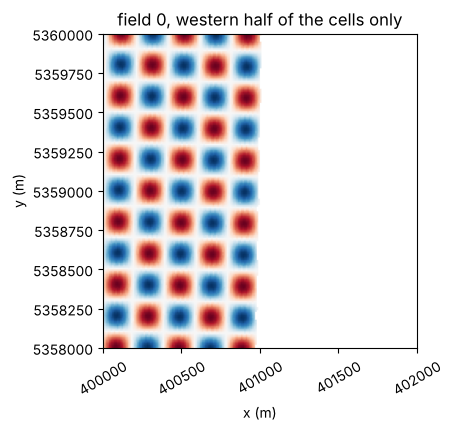

In [9]:
# Suppose the store only holds the western part of the zone.
lon_c, _ = healpix_geo.nested.healpix_to_lonlat(op.cell_ids.astype(np.uint64), LEVEL, ellipsoid="WGS84")
lon_c = (np.asarray(lon_c) + 180.0) % 360.0 - 180.0
available = op.cell_ids[lon_c < np.median(lon_c)]

partial = op.resample(read_cells(available), cell_ids=available)
print(f"pixels with a value: {np.isfinite(partial[0]).mean():.0%}")

fig, ax = plt.subplots(figsize=(4.6, 4.2), constrained_layout=True)
ax.imshow(partial[0], extent=extent, origin="upper", vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_title("field 0, western half of the cells only")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.ticklabel_format(style="plain", useOffset=False)
ax.tick_params(axis="x", labelrotation=30)
plt.show()

## With a real Zarr store

With `xarray`, step 3 becomes a lazy selection: only the chunks that contain the requested cells are read.
The pattern below is not executed here; adapt the names of the dimension and of the variables to your store.

```python
import xarray as xr

ds = xr.open_zarr("s3://bucket/dataset.zarr")        # lazy: nothing is read yet
level = ds.cell_ids.attrs["level"]                   # or the known level of the store

op = HealpixToUTM(grid, level, method="bilinear")    # geometry only

# (a) sparse store: `cell_ids` is an indexed coordinate
sub = ds.sel(cell_ids=op.cell_ids)

# (b) full-sphere store in nested order: the position along the dimension *is* the cell id
sub = ds.isel(cells=op.cell_ids)

data = sub["reflectance"].transpose(..., "cells").values     # (B, K): the only read
image = op.resample(data)                                    # (B, ny, nx)

out = xr.DataArray(
    image, dims=("band", "y", "x"),
    coords={"y": grid.y, "x": grid.x},
    attrs={"crs": grid.crs.to_wkt()},
)
```

Notes:

- `op.cell_ids` is sorted, so the selection reads each chunk at most once.
- If some required cells are missing from a sparse store, select the ones that exist
  (`np.intersect1d(op.cell_ids, ds.cell_ids)`) and pass them to `op.resample(data, cell_ids=...)`.
- For a ring-ordered store, build the operator with `nest=False`.
- For a large zone, process it tile by tile: one operator per tile keeps `K`, and therefore the read, bounded.
- `device="cuda"` builds and applies the operator on GPU; `dtype=torch.float32` halves its memory.